# 04 - Performance Analysis

This notebook reviews generated performance outputs, plots, robustness tables, and benchmark/subperiod diagnostics. It reads existing files produced by `python main.py`.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"

def read_csv_if_exists(path, **kwargs):
    if path.exists():
        return pd.read_csv(path, **kwargs)
    print(f"Missing: {path}")
    return None

## Performance Summary

In [ ]:
performance_summary = read_csv_if_exists(DATA_PROCESSED / "performance_summary.csv", index_col=0)
if performance_summary is not None:
    display(performance_summary)


,value
total_return,12.152829
annualized_return,0.283440
annualized_volatility,0.205044
sharpe_ratio,1.320421
max_drawdown,-0.333005
hit_ratio,0.576095
annualized_active_return,0.109052
tracking_error,0.052847
information_ratio,2.063551


## Existing Report Figures

nav_vs_benchmark.png


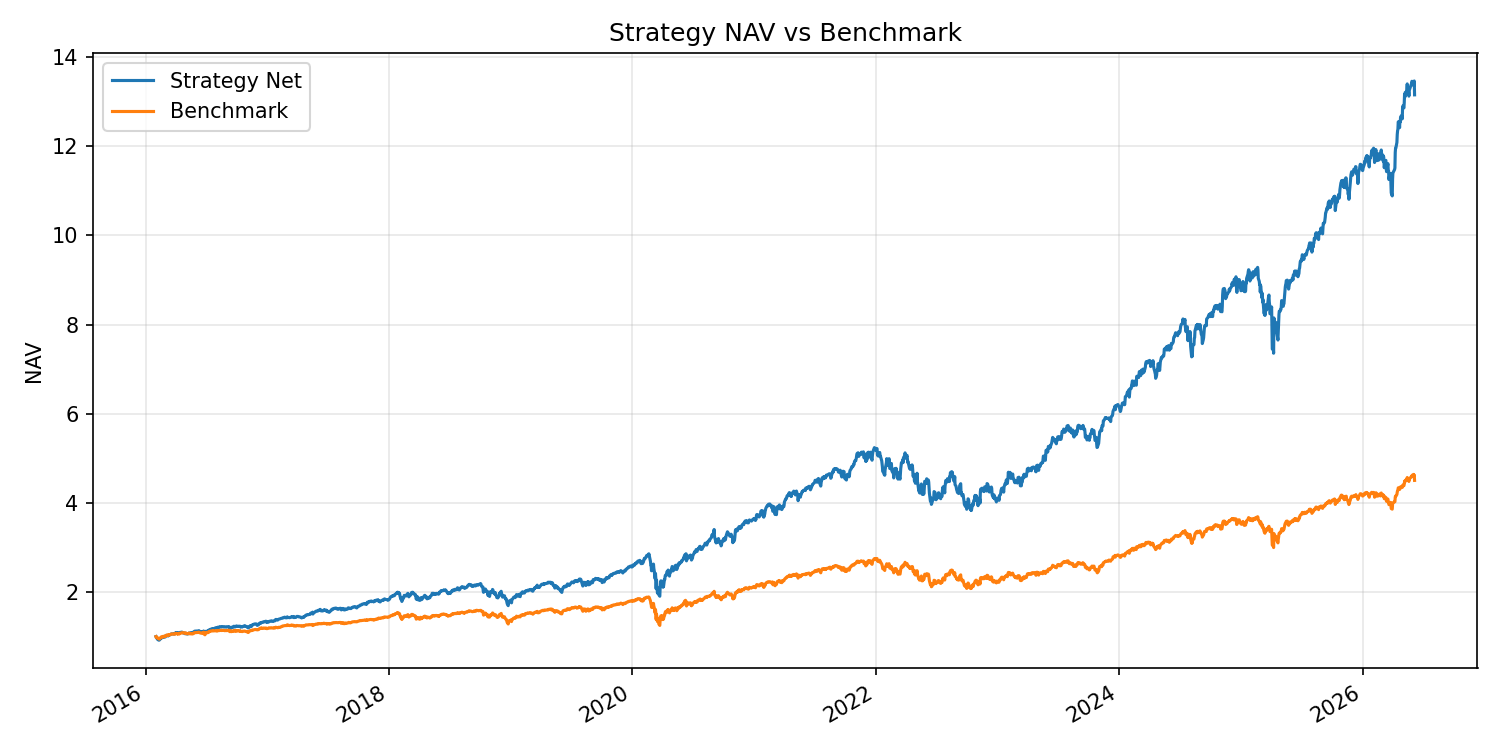

cumulative_active_return.png


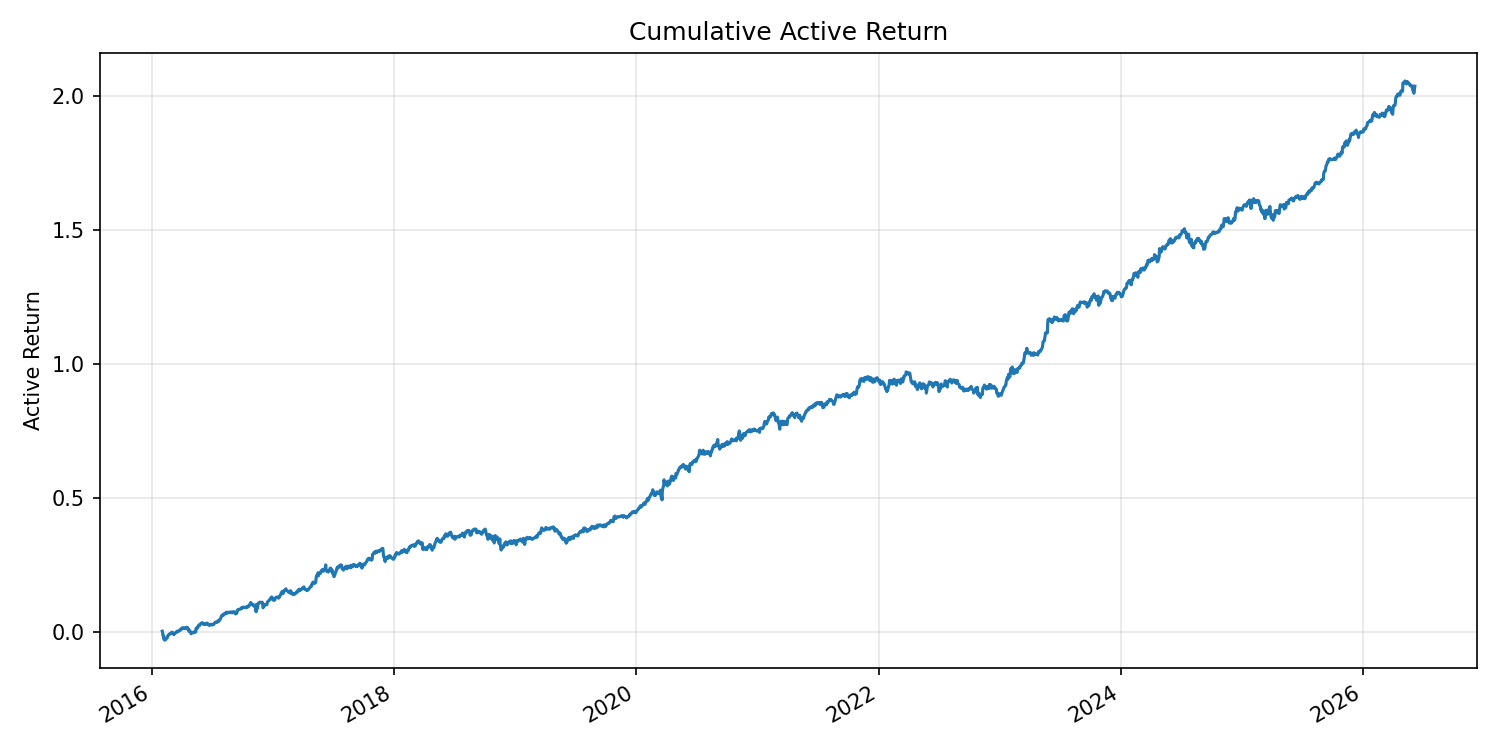

drawdown.png


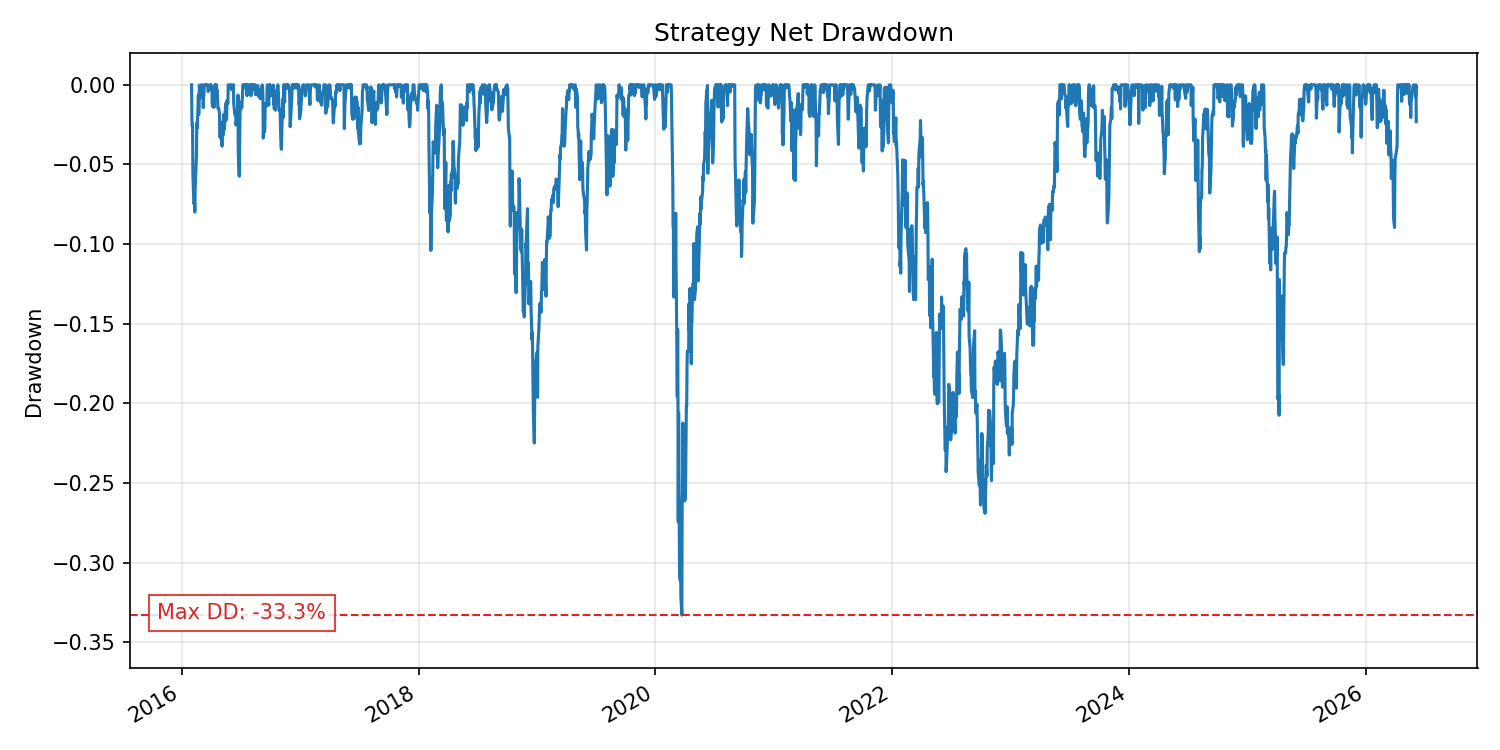

turnover.png


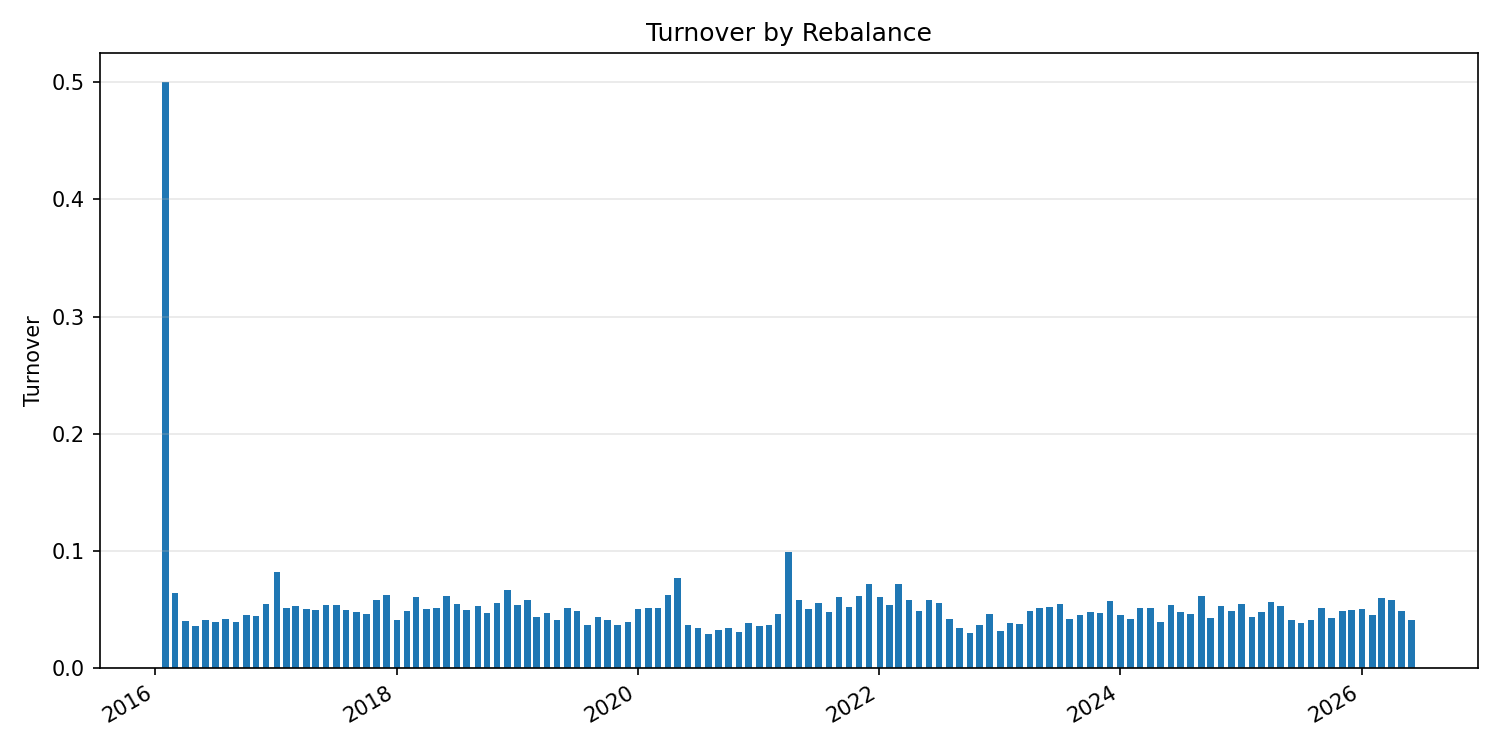

rolling_active_return.png


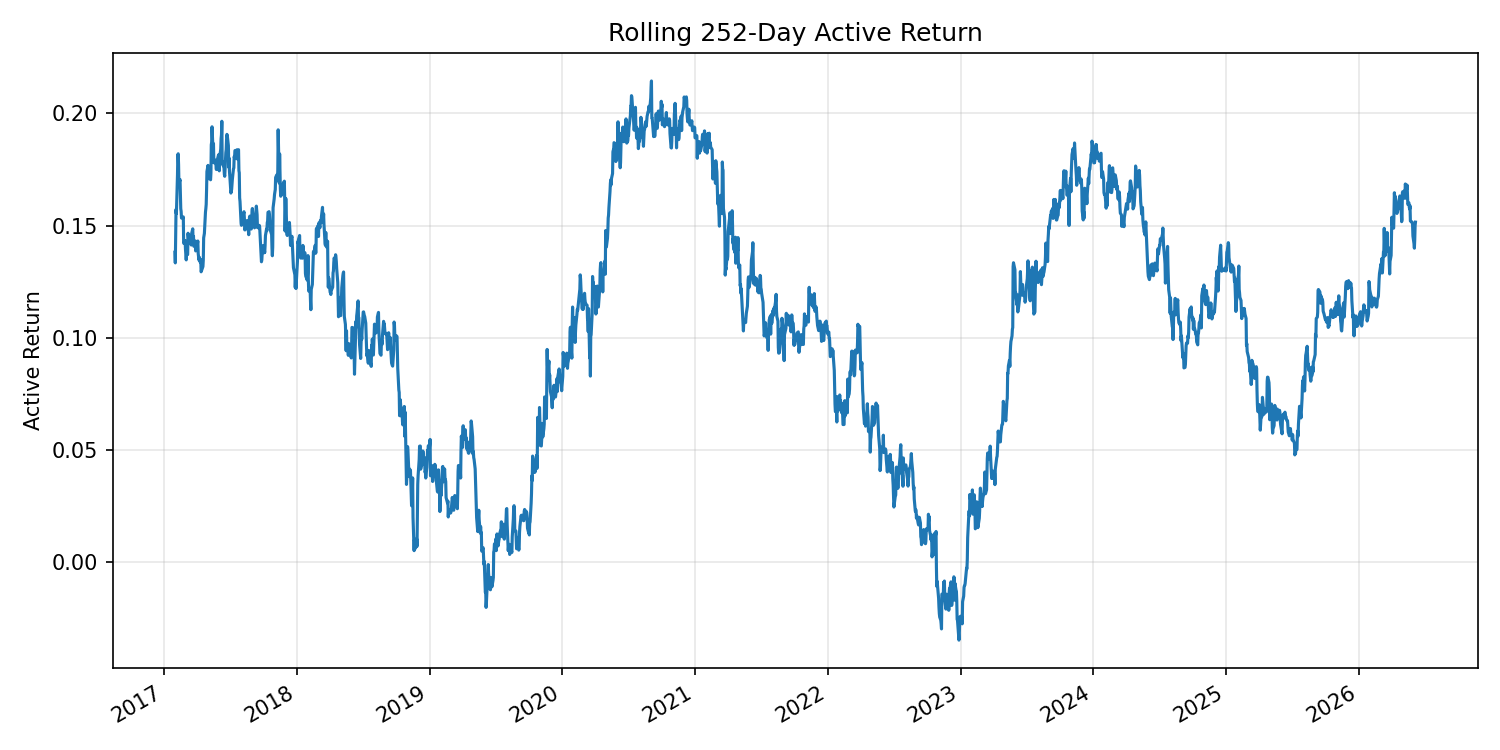

rolling_tracking_error.png


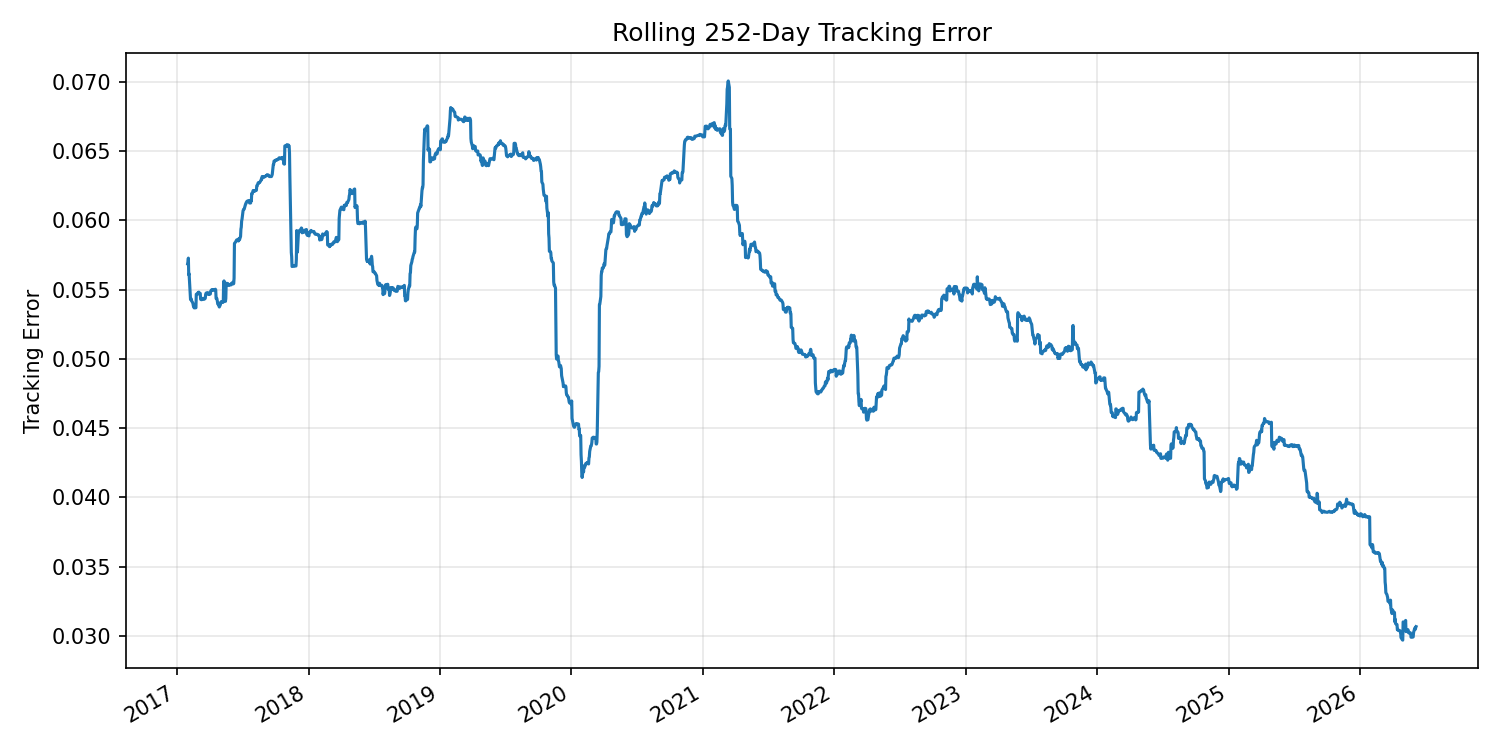

In [3]:
figure_names = [
    "nav_vs_benchmark.png",
    "cumulative_active_return.png",
    "drawdown.png",
    "turnover.png",
    "rolling_active_return.png",
    "rolling_tracking_error.png",
]

for figure_name in figure_names:
    path = FIGURES / figure_name
    if path.exists():
        print(figure_name)
        display(Image(filename=str(path)))
    else:
        print(f"Missing figure: {path}")

## Robustness Tables

In [4]:
cost_sensitivity = read_csv_if_exists(REPORTS / "cost_sensitivity.csv")
active_budget_sensitivity = read_csv_if_exists(REPORTS / "active_budget_sensitivity.csv")
subperiod_performance = read_csv_if_exists(REPORTS / "subperiod_performance.csv")
subperiod_by_benchmark = read_csv_if_exists(REPORTS / "subperiod_by_benchmark.csv")

for name, table in [
    ("Cost Sensitivity", cost_sensitivity),
    ("Active Budget Sensitivity", active_budget_sensitivity),
    ("Subperiod Performance", subperiod_performance),
    ("Subperiod by Benchmark", subperiod_by_benchmark),
]:
    if table is not None:
        print(name)
        display(table)

Cost Sensitivity


,cost_bps,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
0,0.0,12.327352,0.285079,0.205047,1.326635,-0.332940,0.110331,0.052848,2.087700,0.052803,0.633633
1,5.0,12.239807,0.284259,0.205045,1.323529,-0.332973,0.109691,0.052847,2.075645,0.052803,0.633633
2,10.0,12.152829,0.283440,0.205044,1.320421,-0.333005,0.109052,0.052847,2.063551,0.052803,0.633633
3,20.0,11.980562,0.281802,0.205042,1.314200,-0.333071,0.107774,0.052850,2.039246,0.052803,0.633633


Active Budget Sensitivity


,active_budget,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
0,0.1,12.562324,0.287256,0.206255,1.328283,-0.332652,0.112273,0.053450,2.100538,0.031557,0.378684
1,0.2,12.152829,0.283440,0.205044,1.320421,-0.333005,0.109052,0.052847,2.063551,0.052803,0.633633
2,0.3,11.751785,0.279596,0.203955,1.311660,-0.334097,0.105828,0.052231,2.026167,0.070567,0.846799


Subperiod Performance


,period,start_date,end_date,num_observations,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio
0,2015_2019,2015-01-01,2019-12-31,987,1.569197,0.272416,0.156228,1.621080,-0.224991,0.592705,0.095744,0.057469,1.666016
1,2020_2022,2020-01-01,2022-12-31,756,0.596353,0.168718,0.281078,0.696045,-0.333005,0.543651,0.090836,0.057450,1.581125
2,2023_latest,2023-01-01,NaN,859,2.206955,0.407569,0.172719,2.066536,-0.207474,0.585565,0.140375,0.041960,3.345421


Subperiod by Benchmark


,benchmark,period,start_date,end_date,num_observations,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio
0,SPY,2015_2019,2015-01-01,2019-12-31,987,1.569197,0.272416,0.156228,1.621080,-0.224991,0.592705,0.095744,0.057469,1.666016
1,SPY,2020_2022,2020-01-01,2022-12-31,756,0.596353,0.168718,0.281078,0.696045,-0.333005,0.543651,0.090836,0.057450,1.581125
2,SPY,2023_latest,2023-01-01,NaN,859,2.206955,0.407569,0.172719,2.066536,-0.207474,0.585565,0.140375,0.041960,3.345421
3,EqualWeightUniverse,2015_2019,2015-01-01,2019-12-31,987,1.569197,0.272416,0.156228,1.621080,-0.224991,0.592705,0.052322,0.067107,0.779672
4,EqualWeightUniverse,2020_2022,2020-01-01,2022-12-31,756,0.596353,0.168718,0.281078,0.696045,-0.333005,0.543651,0.031654,0.102317,0.309377
5,EqualWeightUniverse,2023_latest,2023-01-01,NaN,859,2.206955,0.407569,0.172719,2.066536,-0.207474,0.585565,0.163203,0.094229,1.731970


## Benchmark/Subperiod Information Ratio Pivot

In [5]:
if subperiod_by_benchmark is not None:
    ir_pivot = subperiod_by_benchmark.pivot(
        index="period",
        columns="benchmark",
        values="information_ratio",
    )
    active_return_pivot = subperiod_by_benchmark.pivot(
        index="period",
        columns="benchmark",
        values="annualized_active_return",
    )

    print("Information ratio by benchmark and subperiod")
    display(ir_pivot)

    print("Annualized active return by benchmark and subperiod")
    display(active_return_pivot)

Information ratio by benchmark and subperiod


benchmark,EqualWeightUniverse,SPY
period,,
2015_2019,0.779672,1.666016
2020_2022,0.309377,1.581125
2023_latest,1.731970,3.345421


Annualized active return by benchmark and subperiod


benchmark,EqualWeightUniverse,SPY
period,,
2015_2019,0.052322,0.095744
2020_2022,0.031654,0.090836
2023_latest,0.163203,0.140375


## Performance Interpretation

Use the robustness tables together rather than focusing on one headline number. The current framework is useful because it exposes how results change under transaction costs, active budget choices, factor mixes, subperiods, and benchmark definitions.

Important limitations remain:

- Static current constituents introduce survivorship bias.
- Static current market-cap benchmark weights introduce look-ahead bias.
- Results depend strongly on benchmark construction.
- Factor IC evidence is weak overall, so apparent portfolio performance should be interpreted cautiously.
- The next research step is to compare the original 12-1 momentum setting against the stronger IC candidate, 6-month no-skip momentum, in a full backtest sensitivity.